In [1]:
import pandas as pd

data_path = "/kaggle/input/datasets/asopozala/bbc-topicfeature-dataset/bbc_topics_features_clean.csv"
df = pd.read_csv(data_path)

print(df.shape)
df.head()


(35311, 25)


,pubDate_dt,year,title,dominant_topic,max_topic_prop,strongly_dominant,n_topics_prop_over_0_1,n_topics_to_cover_0_7,topic_0_prop,topic_1_prop,...,topic_7_prop,topic_8_prop,topic_9_prop,topic_10_prop,topic_11_prop,topic_12_prop,topic_13_prop,topic_14_prop,topic_15_prop,topic_16_prop
0,2022-03-07 08:01:56,2022,Ukraine: Angry Zelensky vows to punish Russian...,2,0.584825,False,2,2,0.000000,0.290344,...,0.0,0.0,0.062162,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.024675
1,2022-03-06 22:49:58,2022,War in Ukraine: Taking cover in a town under a...,2,0.795955,True,2,1,0.000000,0.000000,...,0.0,0.0,0.000000,0.002606,0.007549,0.000000,0.0,0.021646,0.000000,0.000833
2,2022-03-07 00:14:42,2022,Ukraine war 'catastrophic for global food',2,0.461121,False,3,2,0.093836,0.242005,...,0.0,0.0,0.000000,0.000000,0.000000,0.165967,0.0,0.000000,0.000000,0.000000
3,2022-03-07 00:05:40,2022,Manchester Arena bombing: Saffie Roussos's par...,3,0.625660,False,3,2,0.000000,0.018943,...,0.0,0.0,0.000000,0.020105,0.000000,0.003997,0.0,0.040535,0.031616,0.101550
4,2022-03-07 08:15:53,2022,Ukraine conflict: Oil price soars to highest l...,12,0.756366,True,2,1,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.756366,0.0,0.000000,0.000000,0.000000


### Step 2 – Strongly dominant articles: year and topic

Now I focus only on articles where one topic is **strongly dominant** (`strongly_dominant = True`).
For these articles I want to see:
- how many there are in total,
- how many per year,
- and, for each year, how many belong to each dominant topic.


In [2]:
# filter to strongly dominant articles
strong = df[df["strongly_dominant"]].copy()

print("Number of strongly dominant articles:", len(strong), "\n")

# counts by year and dominant_topic
table = strong.pivot_table(
    index="year",
    columns="dominant_topic",
    values="title",
    aggfunc="count"
).fillna(0).astype(int)

print("Strongly dominant articles – counts by year and dominant topic:")
table


Number of strongly dominant articles: 10616 

Strongly dominant articles – counts by year and dominant topic:


dominant_topic,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
year,,,,,,,,,,,,,,,,,
2022,163,136,635,304,174,92,7,166,207,113,280,237,326,162,156,167,112
2023,39,251,247,518,364,112,256,177,209,73,191,178,254,126,297,216,184
2024,4,233,125,328,399,67,215,216,197,311,106,95,108,394,284,236,169


### Step 3 – Top two‑topic combinations per year

Now I focus on articles where **two topics together** explain most of the article:
- I use `n_topics_to_cover_0_7 == 2` to select articles where the top 2 topics already cover ≥ 70% of the topic mass.
- For each of these articles, I take the indices of the **top 2 topic proportions** and form a sorted pair like `2-11`.
- Then, for each year (2022, 2023, 2024), I count these pairs and show the **top 5 most frequent combinations**.


In [3]:
import numpy as np

# 1) select articles where two topics cover ≥ 70%
two_topic = df[df["n_topics_to_cover_0_7"] == 2].copy()

# 2) get matrix of topic proportions
topic_prop_cols = [c for c in df.columns if c.startswith("topic_") and c.endswith("_prop")]
props = two_topic[topic_prop_cols].values

# 3) for each article, find indices of top 2 topics and make a canonical pair "a-b"
top2_indices = np.argsort(props, axis=1)[:, -2:]           # last two = largest
top2_sorted = np.sort(top2_indices, axis=1)                # ensure smaller first
two_topic["top2_pair"] = [f"{a}-{b}" for a, b in top2_sorted]

# 4) for each year, show top 5 most frequent pairs
for year, group in two_topic.groupby("year"):
    print(f"Year {year} – top 5 topic pairs (among n_topics_to_cover_0_7 == 2):")
    print(group["top2_pair"].value_counts().head(5))
    print()


Year 2022 – top 5 topic pairs (among n_topics_to_cover_0_7 == 2):
top2_pair
3-13    147
1-2     139
0-7     139
2-14    112
7-13    106
Name: count, dtype: int64

Year 2023 – top 5 topic pairs (among n_topics_to_cover_0_7 == 2):
top2_pair
3-13    176
4-16    161
1-4     159
1-3     153
0-7     144
Name: count, dtype: int64

Year 2024 – top 5 topic pairs (among n_topics_to_cover_0_7 == 2):
top2_pair
4-16    209
9-11    193
1-4     157
1-11    152
3-13    151
Name: count, dtype: int64



### Step 4 – Top three‑topic combinations per year

Now I look at articles where the **top 3 topics** are needed to reach 70% of the mass (`n_topics_to_cover_0_7 == 3`).  
For each such article I take the indices of the top 3 topic proportions, form a sorted triple like `2-4-12`, and then, per year, list the **top 5 most frequent triples**.


In [4]:
# 1) select articles where three topics cover ≥ 70%
three_topic = df[df["n_topics_to_cover_0_7"] == 3].copy()

# 2) matrix of topic proportions
topic_prop_cols = [c for c in df.columns if c.startswith("topic_") and c.endswith("_prop")]
props3 = three_topic[topic_prop_cols].values

# 3) for each article, indices of top 3 topics, sorted, form "a-b-c"
top3_indices = np.argsort(props3, axis=1)[:, -3:]
top3_sorted = np.sort(top3_indices, axis=1)
three_topic["top3_triple"] = [f"{a}-{b}-{c}" for a, b, c in top3_sorted]

# 4) top 5 triples per year
for year, group in three_topic.groupby("year"):
    print(f"Year {year} – top 5 topic triples (among n_topics_to_cover_0_7 == 3):")
    print(group["top3_triple"].value_counts().head(5))
    print()


Year 2022 – top 5 topic triples (among n_topics_to_cover_0_7 == 3):
top3_triple
3-7-13    37
0-3-13    27
4-6-12    22
4-8-12    21
1-8-11    18
Name: count, dtype: int64

Year 2023 – top 5 topic triples (among n_topics_to_cover_0_7 == 3):
top3_triple
0-3-13     47
4-6-12     32
1-4-14     29
4-10-16    26
3-7-13     25
Name: count, dtype: int64

Year 2024 – top 5 topic triples (among n_topics_to_cover_0_7 == 3):
top3_triple
3-7-13     45
1-4-14     42
0-3-13     37
1-9-11     34
4-14-16    30
Name: count, dtype: int64



### Summary so far – topic dominance patterns

- I focused on articles where the NMF topics have a clear structure, using:
  - `strongly_dominant = True` for articles whose top topic has ≥ 70% of the total mass.
  - `n_topics_to_cover_0_7` to see whether 1, 2, or 3 topics are needed to explain 70% of the article.
- For **strongly dominant** articles, I counted how many there are per **year** and per **dominant_topic**.  
  This shows which topics are “single‑topic stories” and how their frequency changes between 2022, 2023, and 2024.
- For more mixed but focused stories:
  - When `n_topics_to_cover_0_7 == 2`, I looked at the most common **pairs** of top topics per year (e.g. `3-13`, `4-16`, `9-11`).
  - When `n_topics_to_cover_0_7 == 3`, I did the same for **triples** (e.g. `3-7-13`, `4-6-12`, `1-4-14`).
- These patterns reveal stable combinations (like sports topic mixes) and shifts in how conflicts, politics, and cost‑of‑living stories are blended across years, even before choosing any prediction target.


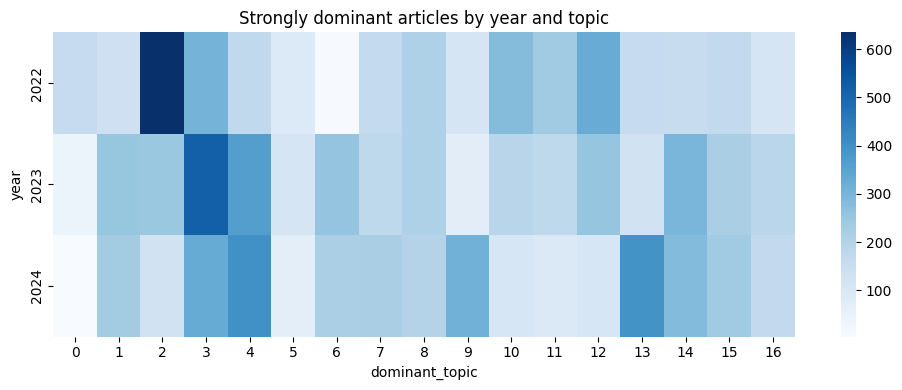

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

strong = df[df["strongly_dominant"]].copy()

heat_table = strong.pivot_table(
    index="year",
    columns="dominant_topic",
    values="title",
    aggfunc="count"
).fillna(0)

plt.figure(figsize=(10, 4))
sns.heatmap(heat_table, cmap="Blues")
plt.title("Strongly dominant articles by year and topic")
plt.xlabel("dominant_topic")
plt.ylabel("year")
plt.tight_layout()
plt.show()


### Step 5 – Heatmap of strongly dominant topics by year

I visualise how many **strongly dominant** articles (max topic ≥ 0.7) each topic has in each year (2022–2024).  
This is a heatmap of counts with:
- rows = year  
- columns = `dominant_topic`  
- colour = number of articles.


### Step 6 – Top 5 two‑topic combinations for a chosen year

I visualise, for one selected year, the **top 5 most common two‑topic mixtures** among articles where  
the top 2 topics are enough to cover 70% of the mass (`n_topics_to_cover_0_7 == 2`).

- Each bar = a pair like `3-13` (two topic indices).
- Height = how many articles in that year have this pair as their top 2 topics.
You can change `target_year` to 2022, 2023 or 2024.


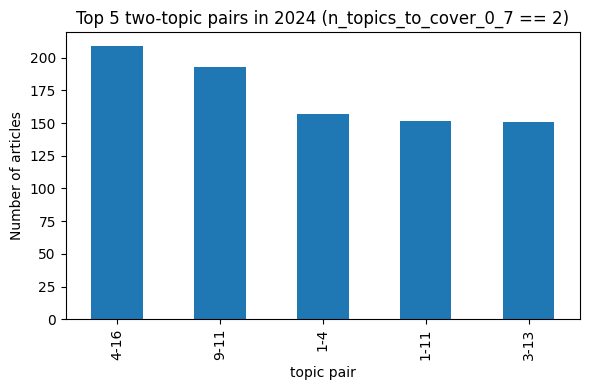

top2_pair
4-16    209
9-11    193
1-4     157
1-11    152
3-13    151
Name: count, dtype: int64

In [6]:
import numpy as np
import matplotlib.pyplot as plt

target_year = 2024  # change to 2022 or 2023 if you like

two_topic = df[df["n_topics_to_cover_0_7"] == 2].copy()
topic_prop_cols = [c for c in df.columns if c.startswith("topic_") and c.endswith("_prop")]
props = two_topic[topic_prop_cols].values

top2_indices = np.argsort(props, axis=1)[:, -2:]
top2_sorted = np.sort(top2_indices, axis=1)
two_topic["top2_pair"] = [f"{a}-{b}" for a, b in top2_sorted]

pairs_year = two_topic[two_topic["year"] == target_year]["top2_pair"]
top5 = pairs_year.value_counts().head(5)

plt.figure(figsize=(6, 4))
top5.plot(kind="bar")
plt.title(f"Top 5 two-topic pairs in {target_year} (n_topics_to_cover_0_7 == 2)")
plt.xlabel("topic pair")
plt.ylabel("Number of articles")
plt.tight_layout()
plt.show()

top5


### Step 7 – Per-topic summary: strong alone vs often in pairs/triples

Goal: for each topic ID, compare:
- how often it appears as a **strong single dominant** topic,
- how often it appears inside the **top-2 pairs** (two-topic dominance),
- how often it appears inside the **top-3 triples** (three-topic dominance).

This will help identify:
- topics that are strong **alone** but rarely mixed, and
- topics that often appear in **combinations** with other topics.


In [7]:
import numpy as np

# --- 1) strong single-dominant counts ---
strong = df[df["strongly_dominant"]].copy()
single_counts = strong["dominant_topic"].value_counts().sort_index()

# --- 2) topic frequency in top-2 pairs (n_topics_to_cover_0_7 == 2) ---
two_topic = df[df["n_topics_to_cover_0_7"] == 2].copy()
topic_prop_cols = [c for c in df.columns if c.startswith("topic_") and c.endswith("_prop")]
props2 = two_topic[topic_prop_cols].values

top2_indices = np.argsort(props2, axis=1)[:, -2:]   # shape (n, 2)
two_flat = top2_indices.flatten()
pair_topic_counts = pd.Series(two_flat).value_counts().sort_index()

# --- 3) topic frequency in top-3 triples (n_topics_to_cover_0_7 == 3) ---
three_topic = df[df["n_topics_to_cover_0_7"] == 3].copy()
props3 = three_topic[topic_prop_cols].values

top3_indices = np.argsort(props3, axis=1)[:, -3:]   # shape (n, 3)
three_flat = top3_indices.flatten()
triple_topic_counts = pd.Series(three_flat).value_counts().sort_index()

# --- 4) combine into one summary table ---
all_topic_ids = sorted(set(single_counts.index)
                       | set(pair_topic_counts.index)
                       | set(triple_topic_counts.index))

summary = pd.DataFrame({
    "single_strong_count": single_counts.reindex(all_topic_ids, fill_value=0),
    "in_pairs_count": pair_topic_counts.reindex(all_topic_ids, fill_value=0),
    "in_triples_count": triple_topic_counts.reindex(all_topic_ids, fill_value=0),
})

summary["pairs_plus_triples"] = summary["in_pairs_count"] + summary["in_triples_count"]

summary


,single_strong_count,in_pairs_count,in_triples_count,pairs_plus_triples
0,206,1176,589,1765
1,620,3510,1424,4934
2,1007,1450,546,1996
3,1150,2053,1049,3102
4,937,2505,2045,4550
5,271,849,659,1508
6,478,953,596,1549
7,559,1848,800,2648
8,613,1828,943,2771
9,497,1311,945,2256


### Step 8 – Visualise isolated vs relational topics

I plot, for each topic ID:
- `single_strong_count` on the x-axis (how often it is a strongly dominant topic),
- `pairs_plus_triples` on the y-axis (how often it appears inside 2- and 3-topic dominances).

Topics far to the right but low on y are **strong alone but rarely combined**.  
Topics high on both axes are **strong and highly relational**.


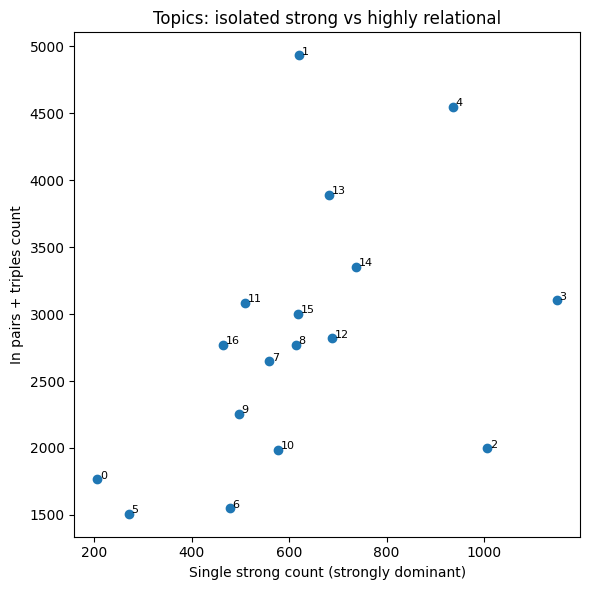

,single_strong_count,in_pairs_count,in_triples_count,pairs_plus_triples
0,206,1176,589,1765
1,620,3510,1424,4934
2,1007,1450,546,1996
3,1150,2053,1049,3102
4,937,2505,2045,4550
5,271,849,659,1508
6,478,953,596,1549
7,559,1848,800,2648
8,613,1828,943,2771
9,497,1311,945,2256


In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(summary["single_strong_count"], summary["pairs_plus_triples"])

for topic_id, row in summary.iterrows():
    plt.text(row["single_strong_count"] + 5,
             row["pairs_plus_triples"] + 5,
             str(topic_id),
             fontsize=8)

plt.xlabel("Single strong count (strongly dominant)")
plt.ylabel("In pairs + triples count")
plt.title("Topics: isolated strong vs highly relational")
plt.tight_layout()
plt.show()

summary
